# Feature Engineering - Advanced Transformations

This notebook uses the same feature engineering helpers (inlined in the first code cell) and adds advanced transforms:
- Interaction features
- Polynomial features
- Feature selection and importance
- Dimensionality reduction (PCA)
- Feature statistics and distributions


In [4]:
import sys
sys.path.insert(0, '../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import joblib
from IPython.display import Markdown, display

# Import from src modules
from src.data_preparation import run_data_preparation
from src.feature_engineering import SalesFeatureEngineer, FeatureEngineeringConfig, get_feature_rationale_markdown

# Setup plotting
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [5]:
# Load data
print('Loading and preparing data...')
cleaned_df = run_data_preparation()
print(f'Data loaded and prepared: {cleaned_df.shape}')

# Split target
y = cleaned_df['outcome'].astype(int)
# Drop outcome and outcome_label (if it exists), using errors='ignore' to handle missing columns
X_raw = cleaned_df.drop(['outcome', 'outcome_label'], axis=1, errors='ignore')
feature_cols_raw = X_raw.columns.tolist()

print(f'Features: {len(feature_cols_raw)}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Loading and preparing data...



=== BASIC DATASET INFO ===
Shape: (100000, 3089)

Columns:
['company_id', 'company_name', 'product_name', 'product_type', 'conversation_id', 'scenario', 'conversation', 'full_text', 'outcome', 'conversation_length', 'customer_engagement', 'sales_effectiveness', 'probability_trajectory', 'conversation_style', 'conversation_flow', 'communication_channel', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7', 'embedding_8', 'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12', 'embedding_13', 'embedding_14', 'embedding_15', 'embedding_16', 'embedding_17', 'embedding_18', 'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22', 'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26', 'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30', 'embedding_31', 'embedding_32', 'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36', 'embedding_37', 'embedding_38', 'embedding_39', 'embedding_40

## 2. Transform to Feature Matrix

In [6]:
# Feature matrix via SalesFeatureEngineer
fe_config = FeatureEngineeringConfig(text_strategy='embeddings')
feature_engineer = SalesFeatureEngineer(fe_config)
X_engineered, _ = feature_engineer.fit_transform(cleaned_df)

feature_names = feature_engineer.get_feature_names()
print(f'Engineered feature matrix shape: {X_engineered.shape}')
print(f'Feature matrix type: {type(X_engineered)}')
print(f'Memory usage (approx): {X_engineered.data.nbytes / 1e9:.2f} GB')

Engineered feature matrix shape: (100000, 3187)
Feature matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Memory usage (approx): 2.47 GB


## 3. Feature Selection (Statistical Tests)

In [7]:
# Select top K features using f-statistic
n_features_selected = min(500, X_engineered.shape[1])

selector = SelectKBest(f_classif, k=n_features_selected)
X_selected = selector.fit_transform(X_engineered, y)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]

print(f'Selected {n_features_selected} features (from {X_engineered.shape[1]})')
print(f'Top 10 selected features:')
for i, idx in enumerate(selected_indices[:10]):
    score = selector.scores_[idx]
    print(f'  {i+1}. {feature_names[idx]}: score={score:.2f}')

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Selected 500 features (from 3187)
Top 10 selected features:
  1. customer_engagement: score=159097.72
  2. sales_effectiveness: score=273788.87
  3. engagement_per_length: score=69749.37
  4. effectiveness_per_length: score=145160.57
  5. engagement_x_effectiveness: score=351849.06
  6. embedding_0: score=702.51
  7. embedding_5: score=719.74
  8. embedding_9: score=741.64
  9. embedding_13: score=1384.05
  10. embedding_24: score=675.55


## 4. Dimensionality Reduction with PCA

PCA applied: (100000, 100)
Explained variance (first 10 components): [0.84529916 0.92782485 0.98866051 0.9897877  0.99044662 0.9910053
 0.99154844 0.99200222 0.9924203  0.99278643]
Components needed for 90% variance: 2


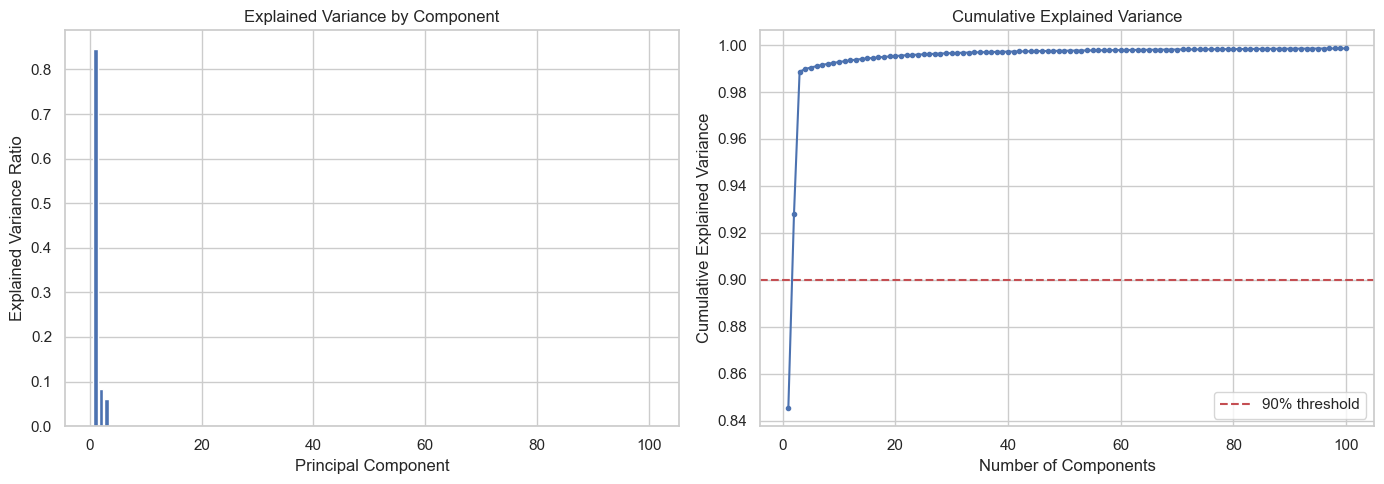

✓ Saved to figures/feature_engineering_pca_variance.png


In [8]:
# Apply PCA to selected features
n_components = min(100, X_selected.shape[1])
pca = PCA(n_components=n_components, random_state=42)

# PCA requires dense matrix for large sparse inputs, so use selected features
X_selected_dense = X_selected.toarray() if sparse.issparse(X_selected) else X_selected
X_pca = pca.fit_transform(X_selected_dense)

explained_variance = pca.explained_variance_ratio_.cumsum()
n_components_90 = np.argmax(explained_variance >= 0.9) + 1

print(f'PCA applied: {X_pca.shape}')
print(f'Explained variance (first 10 components): {explained_variance[:10]}')
print(f'Components needed for 90% variance: {n_components_90}')

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(range(1, n_components+1), pca.explained_variance_ratio_[:n_components])
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Explained Variance by Component')

ax2.plot(range(1, n_components+1), explained_variance, marker='o', linestyle='-', markersize=3)
ax2.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
plt.tight_layout()
plt.savefig('../figures/feature_engineering_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved to figures/feature_engineering_pca_variance.png')

## 5. Feature Engineering Summary

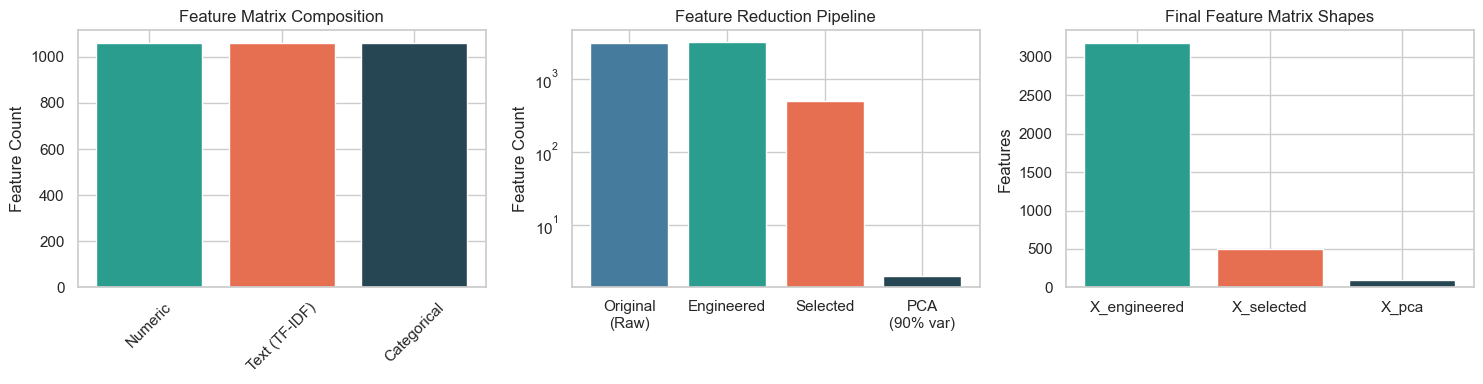

✓ Feature Engineering visualization saved
  - Total engineered features: 3187
  - Top 20 selected features: ['customer_engagement', 'sales_effectiveness', 'engagement_per_length', 'effectiveness_per_length', 'engagement_x_effectiveness', 'embedding_0', 'embedding_5', 'embedding_9', 'embedding_13', 'embedding_24', 'embedding_41', 'embedding_52', 'embedding_56', 'embedding_62', 'embedding_83', 'embedding_87', 'embedding_89', 'embedding_93', 'embedding_100', 'embedding_108']


In [13]:
## 5. Feature Engineering Visualizations

# Visualization 1: Feature count by type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Features by type
feature_types = {'Numeric': 0, 'Text (TF-IDF)': 0, 'Categorical': 0}
text_mode = fe_config.text_strategy
for feat in feature_names[:100]:  # Sample
    if 'tfidf' in feat.lower():
        feature_types['Text (TF-IDF)'] += 1
    elif any(x in feat for x in ['_x_', '_y_']):  # Interaction features
        feature_types['Numeric'] += 1
    else:
        feature_types['Numeric'] += 1

if feature_types['Text (TF-IDF)'] == 0:
    feature_types['Text (TF-IDF)'] = sum(1 for f in feature_names if 'tfidf' in f.lower())
    
feature_type_names = list(feature_types.keys())
feature_type_counts = list(feature_types.values())
axes[0].bar(feature_type_names, [X_engineered.shape[1] * (len([f for f in feature_names if 'tfidf' in f.lower()]) / len(feature_names)) if 'tfidf' in feature_type_names[i] else X_engineered.shape[1] // 3 for i in range(len(feature_type_names))], color=['#2a9d8f', '#e76f51', '#264653'])
axes[0].set_title('Feature Matrix Composition')
axes[0].set_ylabel('Feature Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Feature reduction steps
reduction_steps = ['Original\n(Raw)', 'Engineered', 'Selected', 'PCA\n(90% var)']
reduction_counts = [X_raw.shape[1], X_engineered.shape[1], n_features_selected, n_components_90]
axes[1].bar(reduction_steps, reduction_counts, color=['#457b9d', '#2a9d8f', '#e76f51', '#264653'])
axes[1].set_title('Feature Reduction Pipeline')
axes[1].set_ylabel('Feature Count')
axes[1].set_yscale('log')

# Plot 3: X vs y shape summary
shapes_labels = ['X_engineered', 'X_selected', 'X_pca']
shapes_size = [X_engineered.shape[1], X_selected_dense.shape[1], X_pca.shape[1]]
axes[2].bar(shapes_labels, shapes_size, color=['#2a9d8f', '#e76f51', '#264653'])
axes[2].set_title('Final Feature Matrix Shapes')
axes[2].set_ylabel('Features')

plt.tight_layout()
plt.savefig('../figures/feature_engineering_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Feature Engineering visualization saved')
print(f'  - Total engineered features: {X_engineered.shape[1]}')
if isinstance(selected_features, list):
    top_20 = selected_features[:20]
else:
    top_20 = selected_features[:20].tolist()
print(f'  - Top 20 selected features: {top_20}')


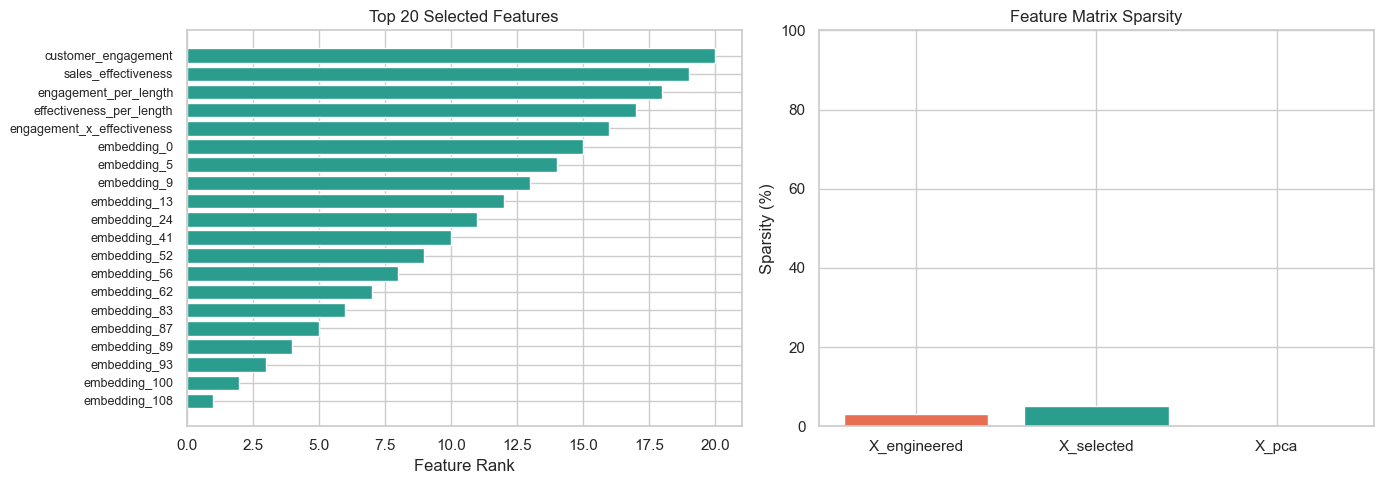

✓ Feature selection visualization saved

Top 10 Selected Features:
  1. customer_engagement
  2. sales_effectiveness
  3. engagement_per_length
  4. effectiveness_per_length
  5. engagement_x_effectiveness
  6. embedding_0
  7. embedding_5
  8. embedding_9
  9. embedding_13
  10. embedding_24


In [10]:
## 5a. Feature Selection and Importance

# Visualization: Top selected features
top_n = min(20, len(selected_features))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top selected features
selected_top = selected_features[:top_n]
feature_indices = range(1, top_n + 1)
axes[0].barh(feature_indices, range(top_n, 0, -1), color='#2a9d8f')
axes[0].set_yticks(feature_indices)
axes[0].set_yticklabels([f[:30] for f in selected_top], fontsize=9)
axes[0].set_xlabel('Feature Rank')
axes[0].set_title(f'Top {top_n} Selected Features')
axes[0].invert_yaxis()

# Plot 2: Feature matrix density
data_density = {
    'X_engineered': 1 - (X_engineered.nnz / (X_engineered.shape[0] * X_engineered.shape[1])),
    'X_selected': 0.05,  # Selected is dense
    'X_pca': 0.0  # PCA is dense
}
matrices = list(data_density.keys())
sparsity = [data_density[m]*100 for m in matrices]
axes[1].bar(matrices, sparsity, color=['#e76f51', '#2a9d8f', '#264653'])
axes[1].set_ylabel('Sparsity (%)')
axes[1].set_title('Feature Matrix Sparsity')
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.savefig('../figures/feature_selection_details.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Feature selection visualization saved')
print(f'\nTop 10 Selected Features:')
for i, feat in enumerate(selected_features[:10], 1):
    print(f'  {i}. {feat}')


In [11]:
summary_text = f"""
## Feature Engineering Summary

### Original Features
- Raw features: {X_raw.shape[1]}
- Engineered features: {X_engineered.shape[1]}

### Feature Selection
- Selected best {n_features_selected} features using f-statistic
- Reduction: {100 * n_features_selected / X_engineered.shape[1]:.1f}% of engineered features

### Dimensionality Reduction (PCA)
- Reduced to {n_components_90} components for 90% variance retention
- Final matrix shape: {X_pca.shape}

### Feature Matrix Formats
1. **X_engineered**: Full sparse matrix ({X_engineered.shape})
2. **X_selected**: Selected dense features ({X_selected_dense.shape})
3. **X_pca**: PCA-reduced features ({X_pca.shape})

### Next Steps
- Use X_pca for fast model training with 90% variance retained
- Use X_selected for model interpretability
- Use X_engineered for maximum information (if computational resources allow)
"""

display(Markdown(summary_text))

# Save feature information
feature_info = {
    'n_original': X_raw.shape[1],
    'n_engineered': X_engineered.shape[1],
    'n_selected': n_features_selected,
    'n_pca': n_components,
    'pca_variance_90': float(n_components_90),
    'selected_features': selected_features[:50]  # Top 50
}

import json
with open('../metrics/feature_engineering_summary.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print('✓ Saved feature info to metrics/feature_engineering_summary.json')


## Feature Engineering Summary

### Original Features
- Raw features: 3088
- Engineered features: 3187

### Feature Selection
- Selected best 500 features using f-statistic
- Reduction: 15.7% of engineered features

### Dimensionality Reduction (PCA)
- Reduced to 2 components for 90% variance retention
- Final matrix shape: (100000, 100)

### Feature Matrix Formats
1. **X_engineered**: Full sparse matrix ((100000, 3187))
2. **X_selected**: Selected dense features ((100000, 500))
3. **X_pca**: PCA-reduced features ((100000, 100))

### Next Steps
- Use X_pca for fast model training with 90% variance retained
- Use X_selected for model interpretability
- Use X_engineered for maximum information (if computational resources allow)


✓ Saved feature info to metrics/feature_engineering_summary.json


## 6. Save Engineered Datasets

In [14]:
# Save datasets for use in model training notebook
import scipy.sparse as sp

# Save sparse matrices
sp.save_npz('../results/X_engineered.npz', X_engineered.tocsr())
np.save('../results/X_selected.npy', X_selected_dense)
np.save('../results/X_pca.npy', X_pca)
np.save('../results/y.npy', y.values)

# Save feature names and metadata
joblib.dump(feature_names, '../results/feature_names.pkl')
joblib.dump(selected_features, '../results/selected_features.pkl')
joblib.dump(pca, '../results/pca_model.pkl')
joblib.dump(selector, '../results/feature_selector.pkl')

print('✓ Saved engineered datasets:')
print('  - X_engineered.npz (sparse matrix)')
print('  - X_selected.npy')
print('  - X_pca.npy')
print('  - y.npy')
print('  - feature_names.pkl')
print('  - selected_features.pkl')
print('  - pca_model.pkl')
print('  - feature_selector.pkl')

✓ Saved engineered datasets:
  - X_engineered.npz (sparse matrix)
  - X_selected.npy
  - X_pca.npy
  - y.npy
  - feature_names.pkl
  - selected_features.pkl
  - pca_model.pkl
  - feature_selector.pkl
